# Lab 4 - part2
### Edge Detection

https://github.com/scikit-image/scikit-image/blob/master/skimage/filters/edges.py

http://scikit-image.org/docs/0.11.x/auto_examples/plot_edge_filter.html

http://scikit-image.org/docs/dev/auto_examples/edges/plot_canny.html



In [4]:
from commonfunctions import *
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
'''
1. Built-in Sobel, Prewill, Roberts, Canny
2. Custom Sobel (V-H-Both)
3. Custom LoG
'''

'\n1. Built-in Sobel, Prewill, Roberts, Canny\n2. Custom Sobel (V-H-Both)\n3. Custom LoG\n'

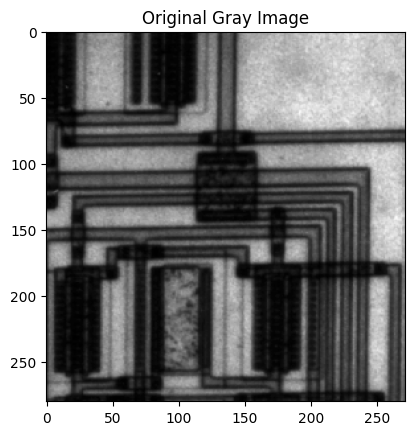

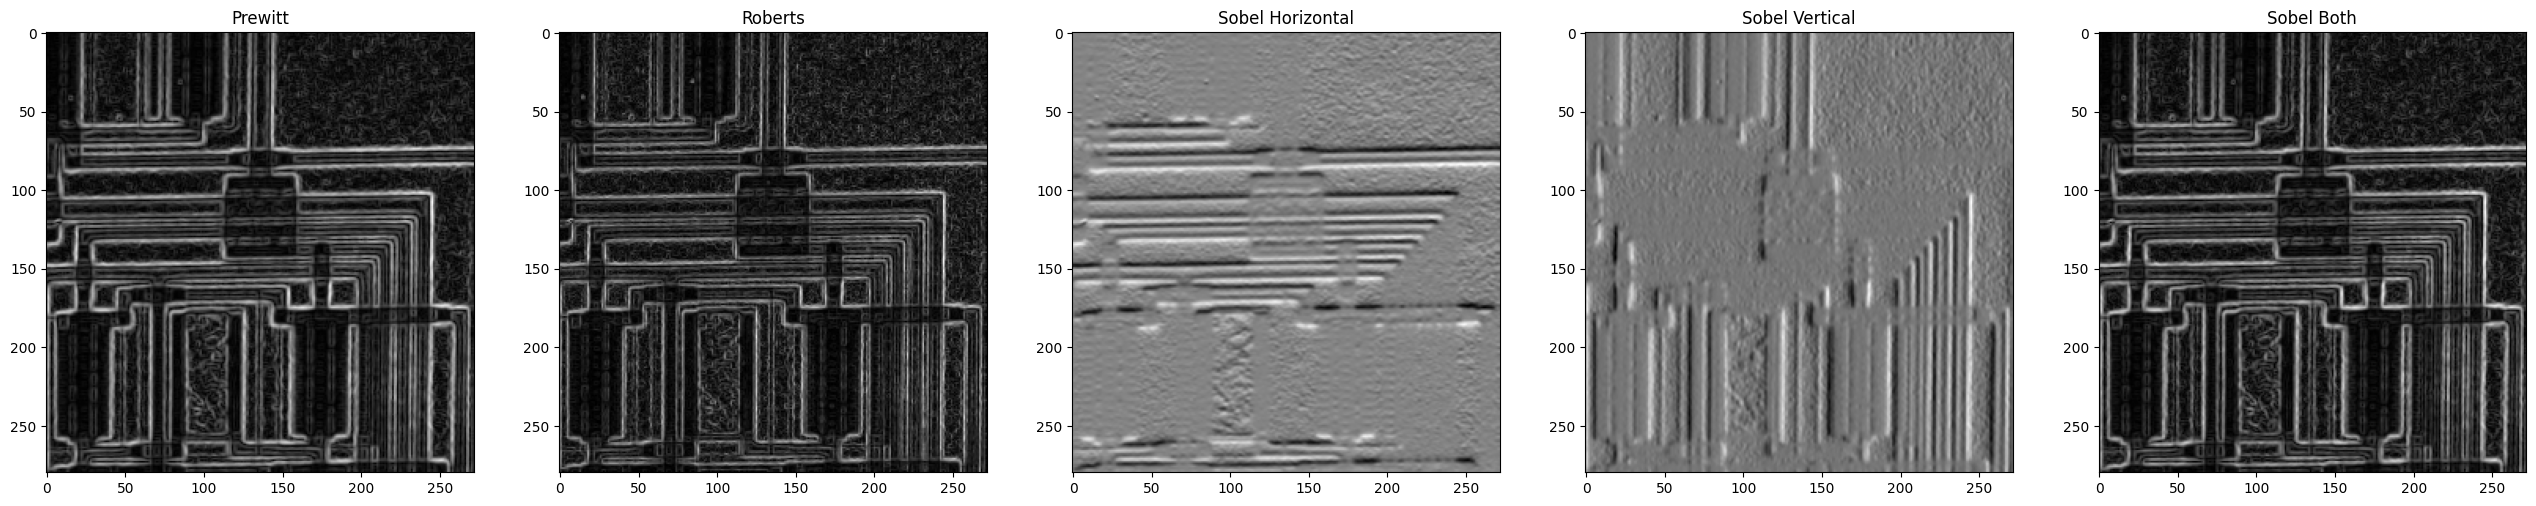

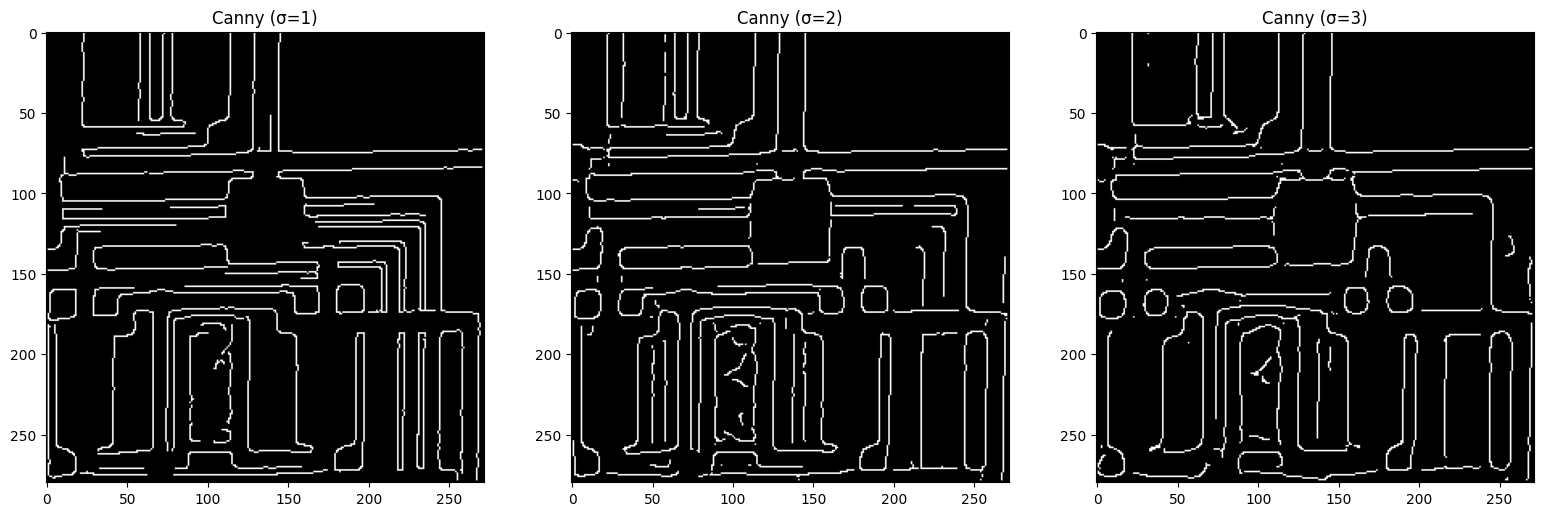

Edge Detection Techniques Comparison:
- Prewitt: Good for detecting edges with less noise sensitivity
- Roberts: Faster but more sensitive to noise, uses 2x2 kernels
- Sobel Horizontal: Detects horizontal edges (top-bottom transitions)
- Sobel Vertical: Detects vertical edges (left-right transitions)
- Sobel Both: Combines horizontal and vertical edge detection
- Canny: Most sophisticated, uses multi-stage algorithm with hysteresis thresholding
  * Lower sigma (σ=1): Detects more fine details but more noise
  * Higher sigma (σ=3): Smoother, fewer false edges but may miss fine details


In [46]:
# 1. Built-in Sobel, Prewitt, Roberts, Canny

# Read the image
img = io.imread('circuit.tif')

# Convert to grayscale if needed (check if image has color channels)
if img.ndim == 3:
    img = rgb2gray(img)

# Display original image
show_images([img], ['Original Gray Image'])

# Apply different edge detection techniques
# Prewitt edge detection
prewitt_edges = prewitt(img)

# Roberts edge detection
roberts_edges = roberts(img)

# Sobel for horizontal edges
sobel_h_edges = sobel_h(img)

# Sobel for vertical edges
sobel_v_edges = sobel_v(img)

# Sobel for both horizontal and vertical edges
sobel_edges = sobel(img)

# Canny edge detection with different sigma values
canny_edges_sigma1 = canny(img, sigma=1.4, low_threshold=50, high_threshold=80)

canny_edges_sigma2 = canny(img, sigma=2.5, low_threshold=20, high_threshold=30)
canny_edges_sigma3 = canny(img, sigma=3.5, low_threshold=7, high_threshold=20)

# Display all edge detection results
show_images([prewitt_edges, roberts_edges, sobel_h_edges, sobel_v_edges, sobel_edges],
            ['Prewitt', 'Roberts', 'Sobel Horizontal', 'Sobel Vertical', 'Sobel Both'])

# Display Canny with different sigma values
show_images([canny_edges_sigma1, canny_edges_sigma2, canny_edges_sigma3],
            ['Canny (σ=1)', 'Canny (σ=2)', 'Canny (σ=3)'])

print("Edge Detection Techniques Comparison:")
print("- Prewitt: Good for detecting edges with less noise sensitivity")
print("- Roberts: Faster but more sensitive to noise, uses 2x2 kernels")
print("- Sobel Horizontal: Detects horizontal edges (top-bottom transitions)")
print("- Sobel Vertical: Detects vertical edges (left-right transitions)")
print("- Sobel Both: Combines horizontal and vertical edge detection")
print("- Canny: Most sophisticated, uses multi-stage algorithm with hysteresis thresholding")
print("  * Lower sigma (σ=1): Detects more fine details but more noise")
print("  * Higher sigma (σ=3): Smoother, fewer false edges but may miss fine details")

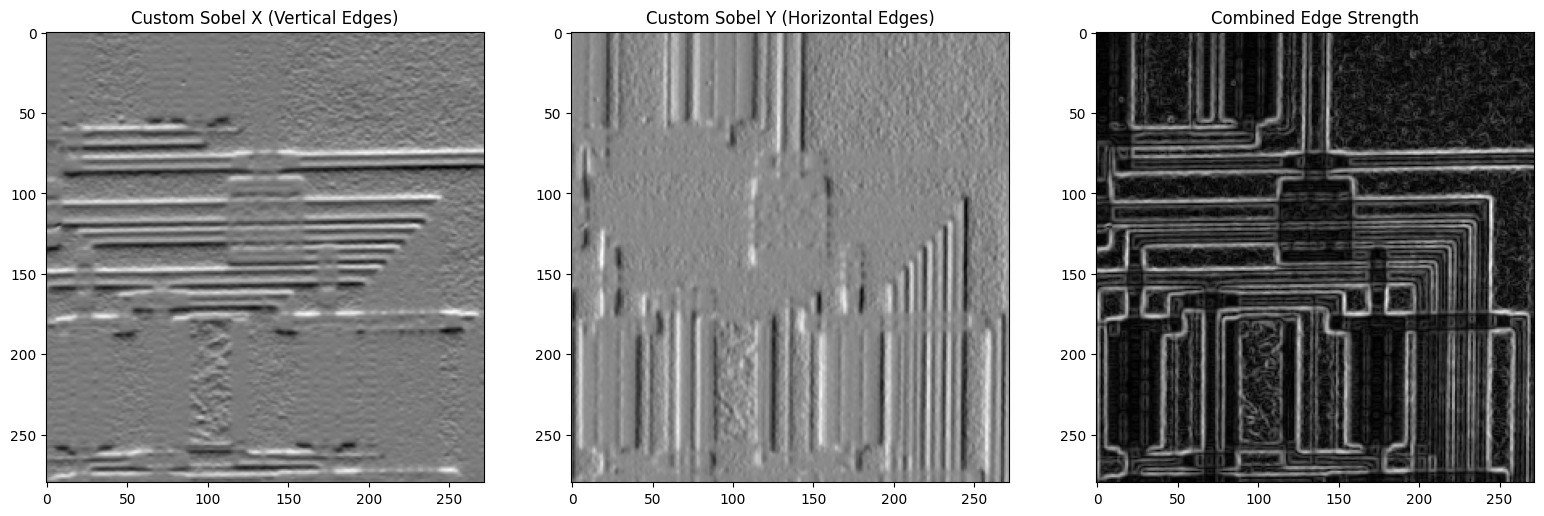

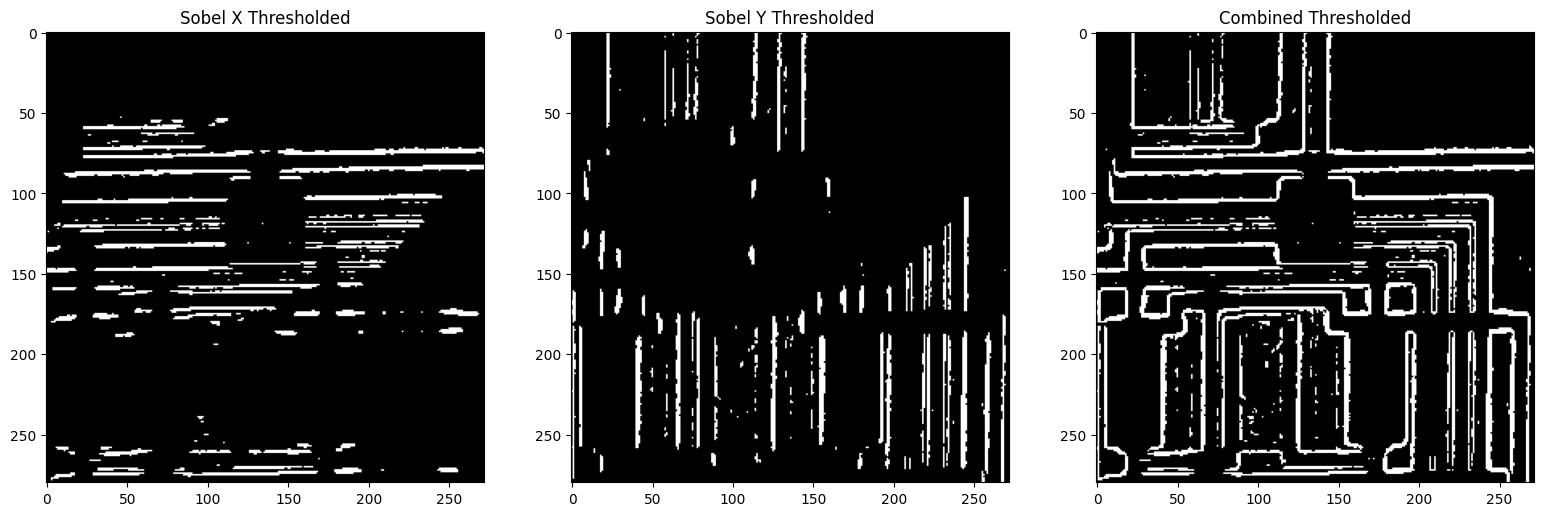

Threshold value used: 122.47
Custom Sobel Implementation:
- X filter (hx): Detects vertical edges by computing horizontal gradients
- Y filter (hy): Detects horizontal edges by computing vertical gradients
- Combined: Uses magnitude √(x² + y²) to detect all edges


In [49]:
# 2. Custom Sobel (V-H-Both)

# Create the two Sobel filters
# hy for horizontal edges (vertical gradient)
hy = np.array([[-1, 0, 1],
               [-2, 0, 2],
               [-1, 0, 1]])

# hx for vertical edges (horizontal gradient)
hx = np.array([[-1, -2, -1],
               [0, 0, 0],
               [1, 2, 1]])

# Apply convolution using the filters
# convolve2d performs the 3x3 window multiplication
sobel_x = convolve2d(img, hx, mode='same', boundary='symm')
sobel_y = convolve2d(img, hy, mode='same', boundary='symm')

# Calculate edge strength using the formula: sqrt(x^2 + y^2)
edge_strength = np.sqrt(sobel_x**2 + sobel_y**2)

# Apply threshold to the edge strength
threshold = 0.378 * edge_strength.max()
sobel_x_thresholded = (np.abs(sobel_x) > threshold).astype(float)
sobel_y_thresholded = (np.abs(sobel_y) > threshold).astype(float)
edge_strength_thresholded = (edge_strength > threshold).astype(float)

# Display results
show_images([sobel_x, sobel_y, edge_strength],
            ['Custom Sobel X (Vertical Edges)', 'Custom Sobel Y (Horizontal Edges)', 'Combined Edge Strength'])

show_images([sobel_x_thresholded, sobel_y_thresholded, edge_strength_thresholded],
            ['Sobel X Thresholded', 'Sobel Y Thresholded', 'Combined Thresholded'])

print(f"Threshold value used: {threshold:.2f}")
print("Custom Sobel Implementation:")
print("- X filter (hx): Detects vertical edges by computing horizontal gradients")
print("- Y filter (hy): Detects horizontal edges by computing vertical gradients")
print("- Combined: Uses magnitude √(x² + y²) to detect all edges")

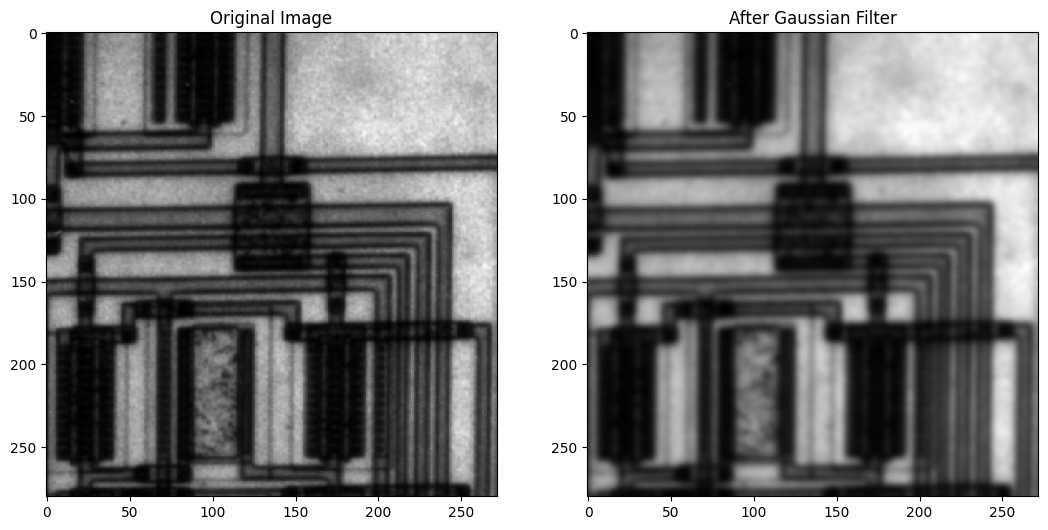

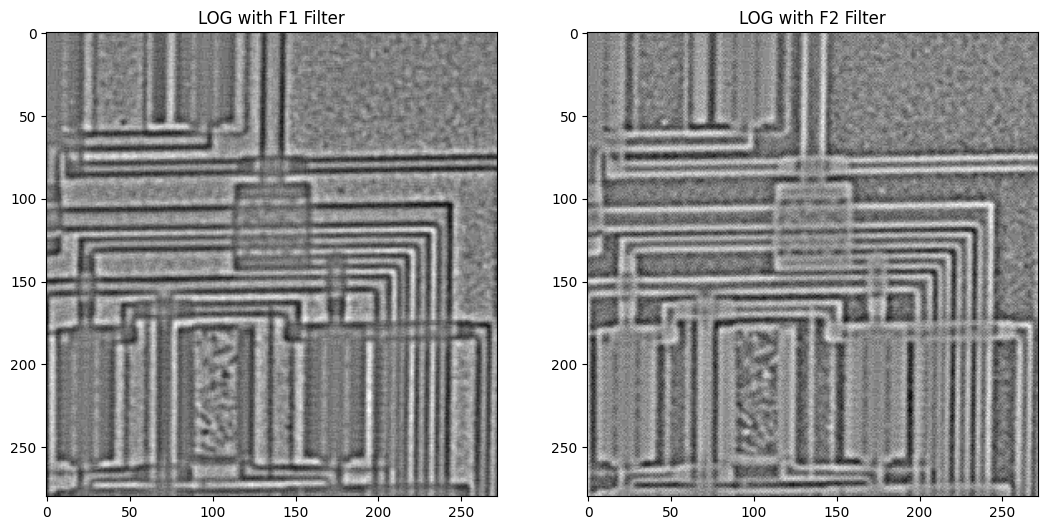

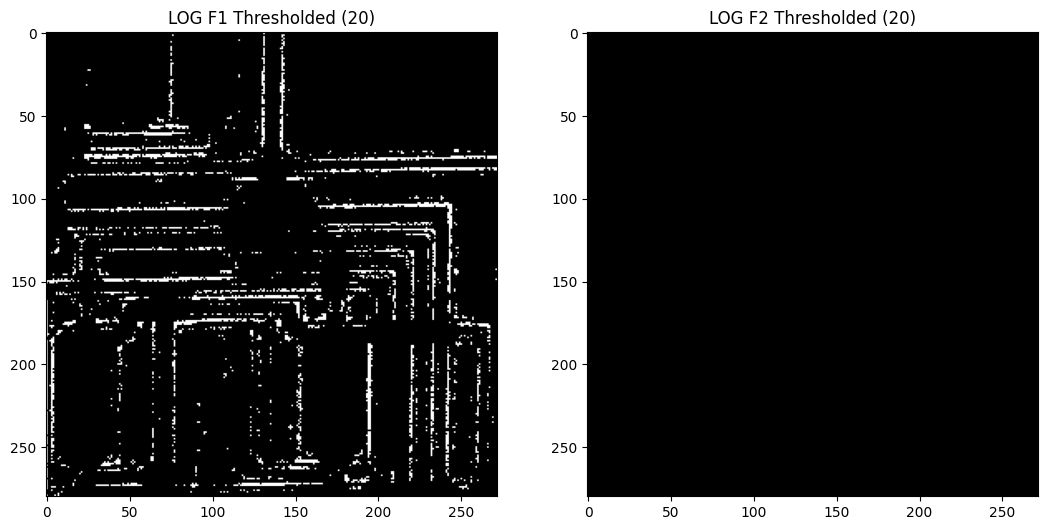

Threshold value used: 20
Laplacian of Gaussian (LOG) Implementation:
- Gaussian filter (σ=1.5): Removes noise before edge detection
- F1 filter: 3x3 Laplacian filter emphasizing central pixel
- F2 filter: Cross-shaped Laplacian filter
- Both filters detect edges as zero-crossings in second derivative


In [16]:
# 3. Custom LoG
thres = 20

# Step 1: Apply Gaussian filter to remove noise
from scipy.ndimage import gaussian_filter
img_gaussian = gaussian_filter(img, sigma=1.5)

# Step 2: Create two types of LOG filters
# F1 filter
F1 = np.array([[-1, -1, -1],
               [-1, 8, -1],
               [-1, -1, -1]])

# F2 filter
F2 = np.array([[0, 1, 0],
               [1, -4, 1],
               [0, 1, 0]])

# Step 3: Apply convolution with both filters
log_f1 = convolve2d(img_gaussian, F1, mode='same', boundary='symm')
log_f2 = convolve2d(img_gaussian, F2, mode='same', boundary='symm')

# Step 4: Apply threshold
log_f1_thresholded = (np.abs(log_f1) > thres).astype(float)
log_f2_thresholded = (np.abs(log_f2) > thres).astype(float)

# Step 5: Display results
show_images([img, img_gaussian],
            ['Original Image', 'After Gaussian Filter'])

show_images([log_f1, log_f2],
            ['LOG with F1 Filter', 'LOG with F2 Filter'])

show_images([log_f1_thresholded, log_f2_thresholded],
            [f'LOG F1 Thresholded ({thres})', f'LOG F2 Thresholded ({thres})'])

print(f"Threshold value used: {thres}")
print("Laplacian of Gaussian (LOG) Implementation:")
print("- Gaussian filter (σ=1.5): Removes noise before edge detection")
print("- F1 filter: 3x3 Laplacian filter emphasizing central pixel")
print("- F2 filter: Cross-shaped Laplacian filter")
print("- Both filters detect edges as zero-crossings in second derivative")

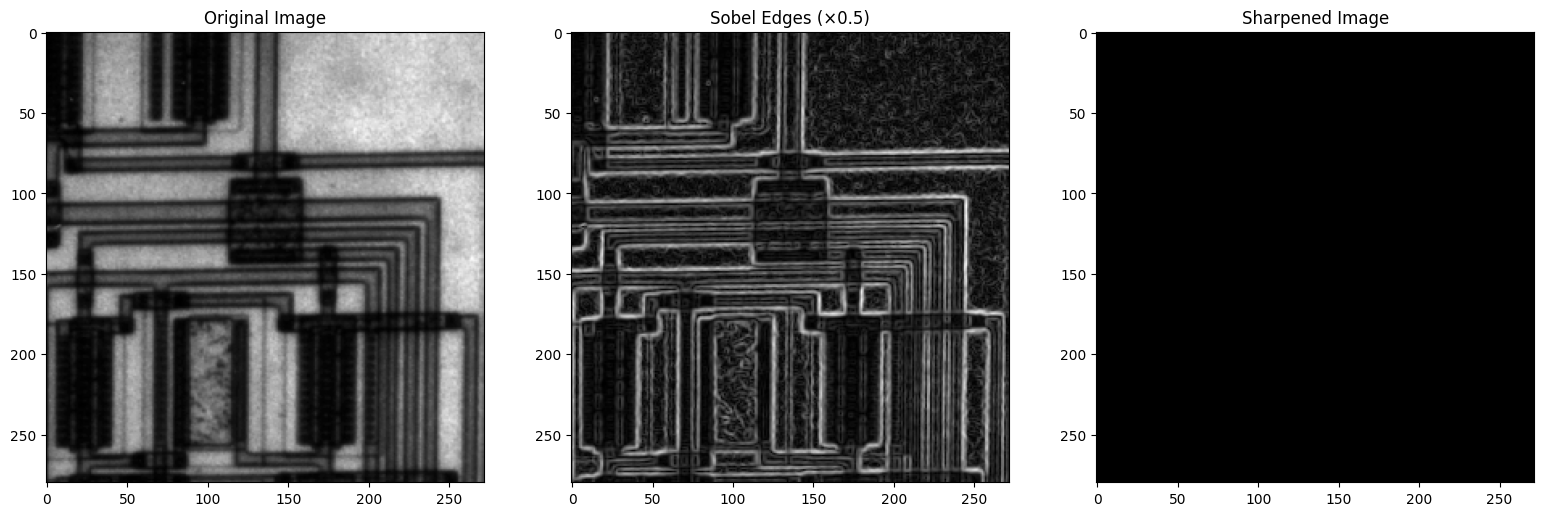

Edge Sharpening Process:
1. Detected edges using Sobel filter
2. Scaled edges by factor 0.5
3. Subtracted scaled edges from original to enhance details
Result: Enhanced image with more prominent features


In [17]:
'''
Optional: Edge Sharpening
1-Make edge detection
2-Multiply by factor < 1
3-Subtract (Original Image) - (Edge Detection Image)
'''

# Perform edge detection using Sobel
edges = sobel(img)

# Multiply edges by a factor < 1 (e.g., 0.5)
edge_factor = 0.5
edges_scaled = edges * edge_factor

# Normalize to match image range
edges_scaled = edges_scaled / edges_scaled.max()

# Subtract edges from original to sharpen
sharpened = img - edges_scaled

# Clip values to valid range [0, 1]
sharpened = np.clip(sharpened, 0, 1)

# Display results
show_images([img, edges, sharpened],
            ['Original Image', f'Sobel Edges (×{edge_factor})', 'Sharpened Image'])

print("Edge Sharpening Process:")
print(f"1. Detected edges using Sobel filter")
print(f"2. Scaled edges by factor {edge_factor}")
print(f"3. Subtracted scaled edges from original to enhance details")
print("Result: Enhanced image with more prominent features")